In [4]:
import serial
import time

s = serial.Serial('/dev/ttyUSB1', 460800, timeout=1)
time.sleep(0.1)

# send reset command
s.write(b'\xA5\x40')
time.sleep(2)
print("bytes after reset:", s.in_waiting)
s.close()

bytes after reset: 21


In [5]:
import serial
import time

s = serial.Serial('/dev/ttyUSB1', 460800, timeout=1)
time.sleep(0.1)

s.write(b'\xA5\x40')
time.sleep(2)
data = s.read(s.in_waiting)
print("raw bytes:", data.hex())
s.close()

raw bytes: 5250205332204c494441522053797374656d2e0d0a


In [6]:
print(bytes.fromhex('5250205332204c494441522053797374656d2e0d0a').decode('ascii'))

RP S2 LIDAR System.



In [1]:
from rplidar import RPLidar

lidar = RPLidar('/dev/ttyUSB1', baudrate=460800)
info = lidar.get_info()
print(info)
lidar.stop()
lidar.disconnect()

{'model': 65, 'firmware': (1, 2), 'hardware': 18, 'serialnumber': '8AE9E195C1E79ED8B5E29EF10E3E4A7D'}


In [2]:
# after having issue with RPLidar library, trying PyRPLidar

from pyrplidar import PyRPlidar

lidar = PyRPlidar()
lidar.connect(port="/dev/ttyUSB1", baudrate=460800, timeout=3)
info = lidar.get_info()
print(info)
lidar.disconnect()

PyRPlidar Info : device is connected
{'model': 65, 'firmware_minor': 2, 'firmware_major': 1, 'hardware': 18, 'serialnumber': '8AE9E195C1E79ED8B5E29EF10E3E4A7D'}
PyRPlidar Info : device is disconnected


In [4]:
from pyrplidar import PyRPlidar
import time

lidar = PyRPlidar()
lidar.connect(port="/dev/ttyUSB1", baudrate=460800, timeout=3)

scan_generator = lidar.start_scan()

for i, scan in enumerate(scan_generator()):
    print(scan)
    if i >= 20:
        break

lidar.stop()
lidar.disconnect()

PyRPlidar Info : device is connected
{'start_flag': False, 'quality': 0, 'angle': 151.0, 'distance': 0.0}
{'start_flag': False, 'quality': 0, 'angle': 151.703125, 'distance': 0.0}
{'start_flag': False, 'quality': 7, 'angle': 152.421875, 'distance': 7055.5}
{'start_flag': False, 'quality': 0, 'angle': 153.125, 'distance': 0.0}
{'start_flag': False, 'quality': 0, 'angle': 153.828125, 'distance': 0.0}
{'start_flag': False, 'quality': 0, 'angle': 154.53125, 'distance': 0.0}
{'start_flag': False, 'quality': 0, 'angle': 155.234375, 'distance': 0.0}
{'start_flag': False, 'quality': 7, 'angle': 155.9375, 'distance': 3559.5}
{'start_flag': False, 'quality': 0, 'angle': 156.734375, 'distance': 0.0}
{'start_flag': False, 'quality': 24, 'angle': 157.453125, 'distance': 3098.5}
{'start_flag': False, 'quality': 29, 'angle': 158.1875, 'distance': 3060.5}
{'start_flag': False, 'quality': 28, 'angle': 158.90625, 'distance': 3077.5}
{'start_flag': False, 'quality': 28, 'angle': 159.578125, 'distance': 3

PyRPlidar Info : device is connected
PyRPlidar Info : device is disconnected


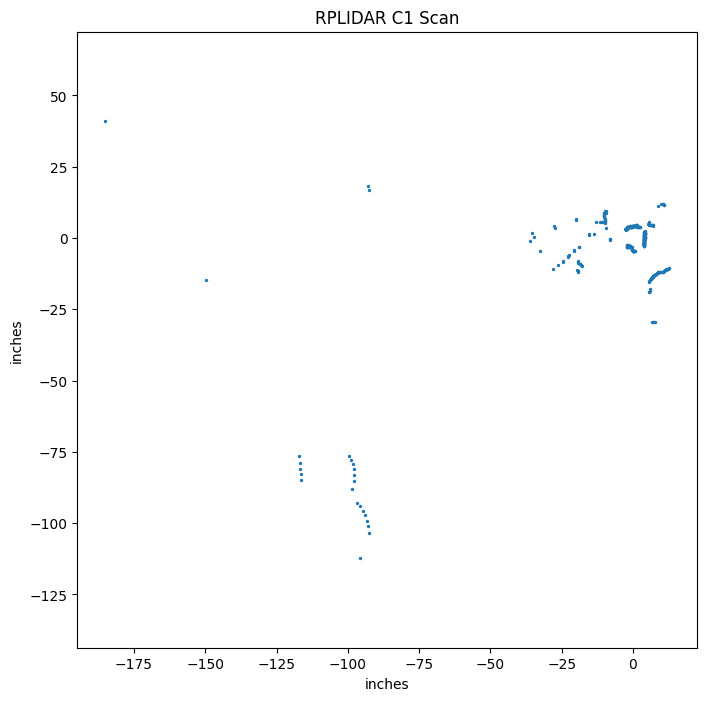

plotted 361 points


In [1]:
from pyrplidar import PyRPlidar
import serial
import time
import matplotlib.pyplot as plt
import numpy as np

# reset first
s = serial.Serial('/dev/ttyUSB1', 460800, timeout=1)
s.write(b'\xA5\x40')
time.sleep(2)
s.read(s.in_waiting)
s.close()
time.sleep(0.5)

lidar = PyRPlidar()
lidar.connect(port="/dev/ttyUSB1", baudrate=460800, timeout=3)

scan_generator = lidar.start_scan()

points = []
for i, scan in enumerate(scan_generator()):
    if scan.quality > 0 and scan.distance > 0:
        points.append((scan.angle, scan.distance))
    if i >= 500:
        break

lidar.stop()
lidar.disconnect()

angles = np.radians([p[0] for p in points])
distances_in = np.array([p[1] for p in points]) / 25.4
x = distances_in * np.cos(angles)
y = distances_in * np.sin(angles)

plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=2)
plt.axis('equal')
plt.title('RPLIDAR C1 Scan')
plt.xlabel('inches')
plt.ylabel('inches')
plt.savefig('../data/scan1.png')
plt.show()
print(f"plotted {len(points)} points")

PyRPlidar Info : device is connected
PyRPlidar Info : device is disconnected


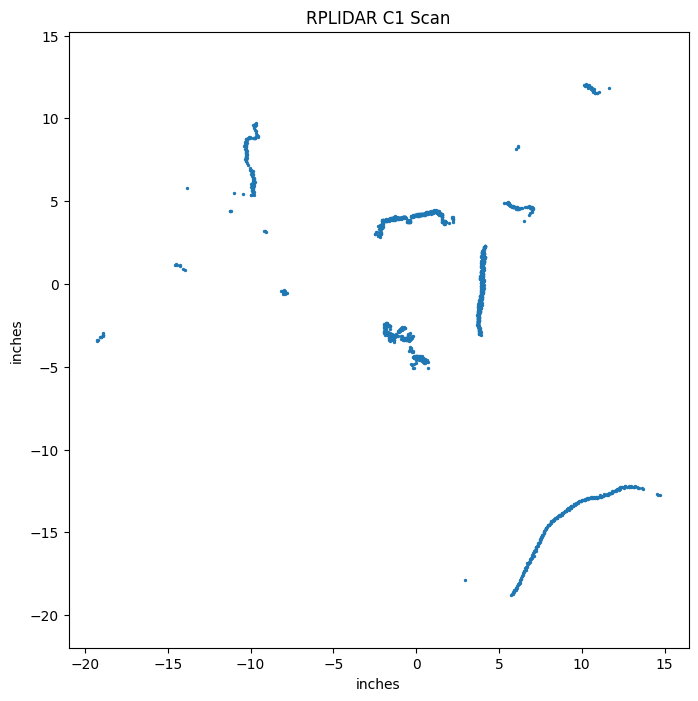

plotted 1672 points


In [2]:
from pyrplidar import PyRPlidar
import serial
import time
import matplotlib.pyplot as plt
import numpy as np
import os

# reset first
s = serial.Serial('/dev/ttyUSB1', 460800, timeout=1)
s.write(b'\xA5\x40')
time.sleep(2)
s.read(s.in_waiting)
s.close()
time.sleep(0.5)

lidar = PyRPlidar()
lidar.connect(port="/dev/ttyUSB1", baudrate=460800, timeout=3)

scan_generator = lidar.start_scan()

points = []
for i, scan in enumerate(scan_generator()):
    if scan.quality > 10 and 0 < scan.distance < 500:  # under ~20 inches
        points.append((scan.angle, scan.distance))
    if i >= 3000:
        break

lidar.stop()
lidar.disconnect()

angles = np.radians([p[0] for p in points])
distances_in = np.array([p[1] for p in points]) / 25.4
x = distances_in * np.cos(angles)
y = distances_in * np.sin(angles)

plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=2)
plt.axis('equal')
plt.title('RPLIDAR C1 Scan')
plt.xlabel('inches')
plt.ylabel('inches')
plt.savefig('../data/scan2.png')
plt.show()
print(f"plotted {len(points)} points")